In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from scipy.stats import t, f

np.set_printoptions(suppress=True)

### Задание 4. Тренд, сезонность, ACF ###

#### *Загрузка данных* ####

In [2]:
df = pd.read_excel("TimeSeries.xls", sheet_name=None)
data_p = df[list(df.keys())[0]].values.flatten()[1:]
data_q = df[list(df.keys())[1]].values.flatten()[1::2][1:]

time_p = np.array([i * 4 for i in range(len(data_p))])
time_q = np.array([i * 2 for i in range(len(data_q))])

#### *Тренд* ####

1. Постройте график зависимости давления от времени (“облако точек”) и его автокорреляционную функцию (ACF).
Определите, является ли временной ряд стационарным.

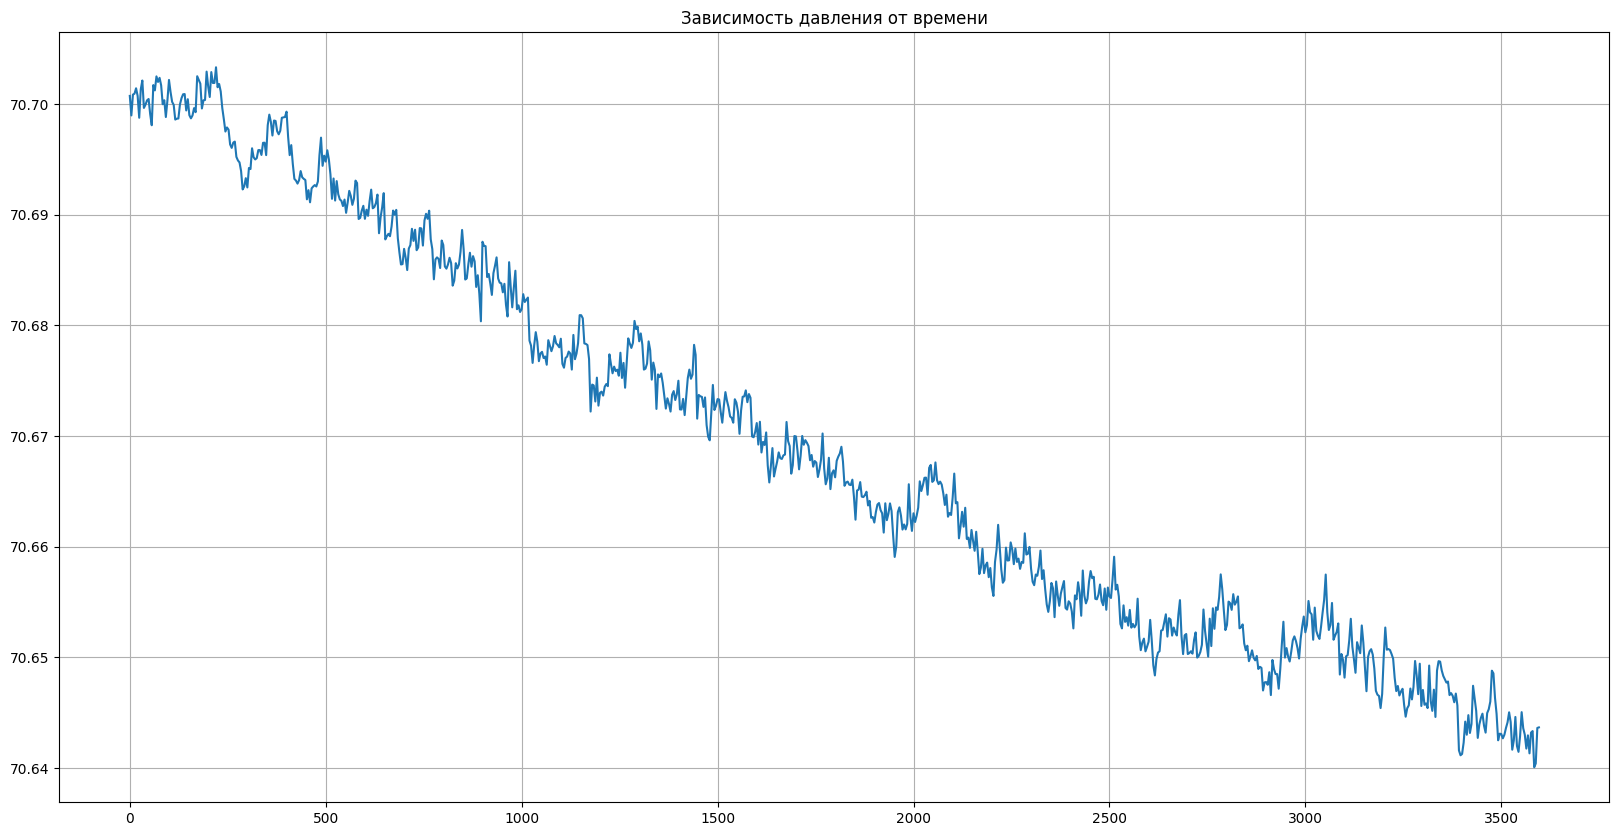

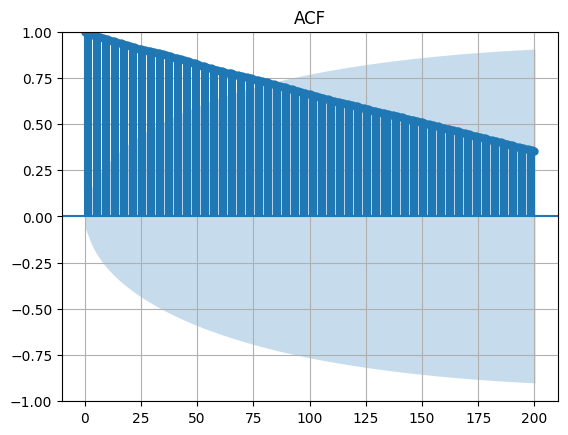

In [3]:
plt.figure(figsize=(20, 10))
plt.plot(time_p, data_p)
plt.title("Зависимость давления от времени")
plt.grid()
plt.show()

plot_acf(data_p, lags=200)
plt.title("ACF")
plt.grid()
plt.show()

2. Попробуйте привести ряд к стационарному виду двумя методами:

(а) методом наименьших квадратов оцените линейный тренд;

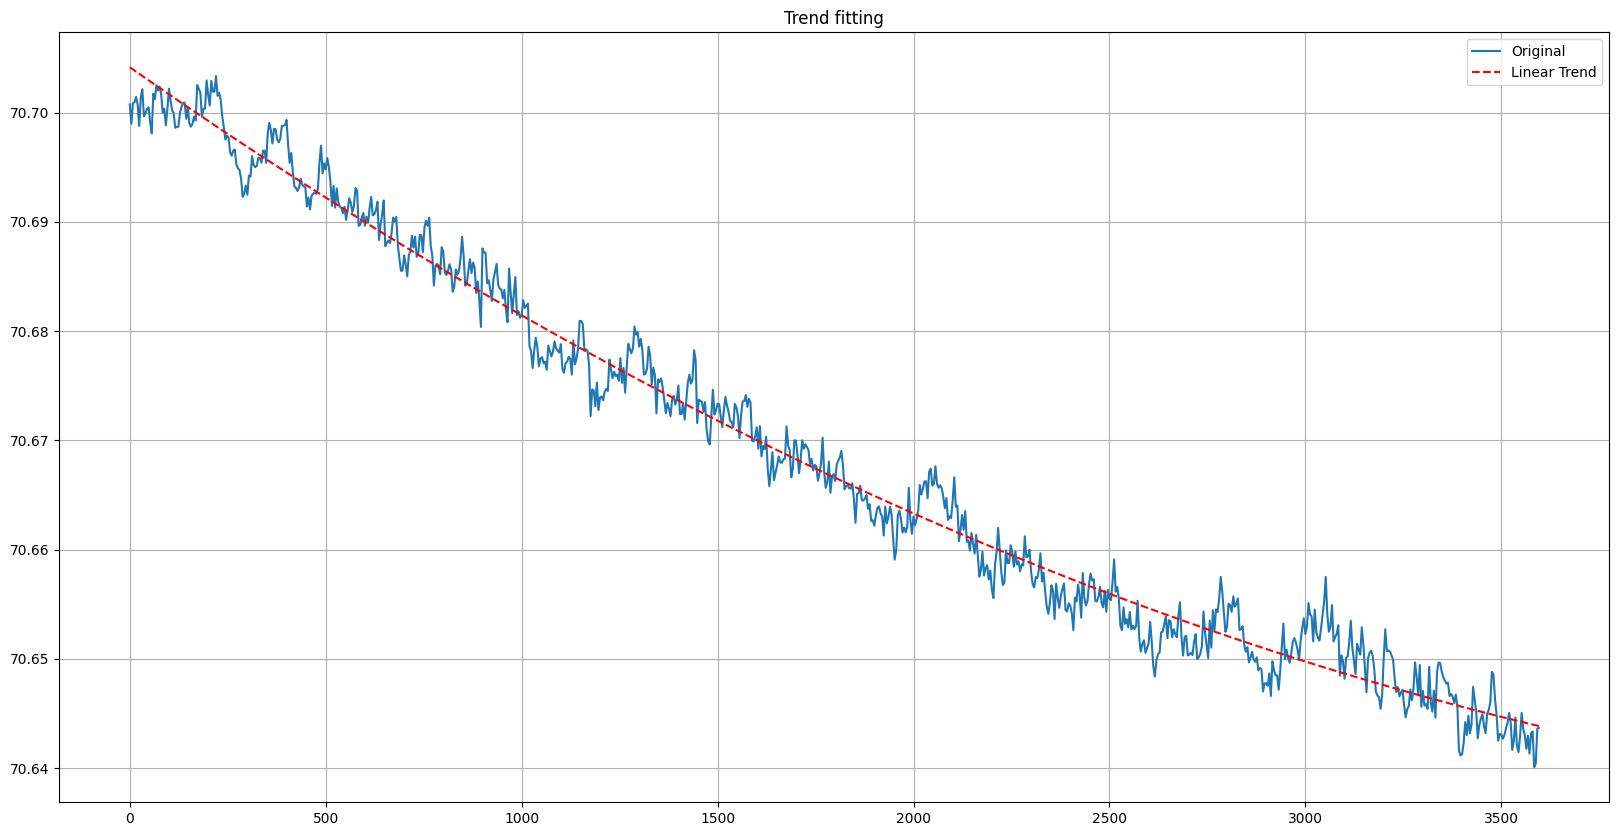

In [4]:
coef = np.polyfit(time_p, data_p, 2)
# trend = coef[0] * time_p + coef[1] 
trend = np.polyval(coef, time_p)
data_p_mnk = data_p - trend

plt.figure(figsize=(20, 10))
plt.plot(time_p, data_p, label="Original")
plt.plot(time_p, trend, 'r', label="Linear Trend", linestyle="--",)
plt.legend()
plt.title("Trend fitting")
plt.grid()
plt.show()

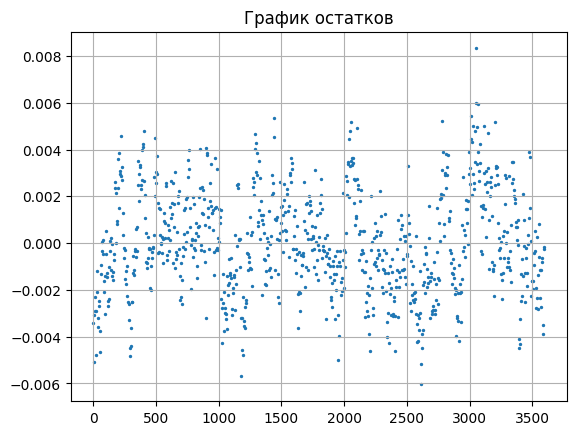

In [5]:
plt.scatter(time_p, data_p_mnk, s=2)
plt.title("График остатков")
plt.grid()
plt.show()

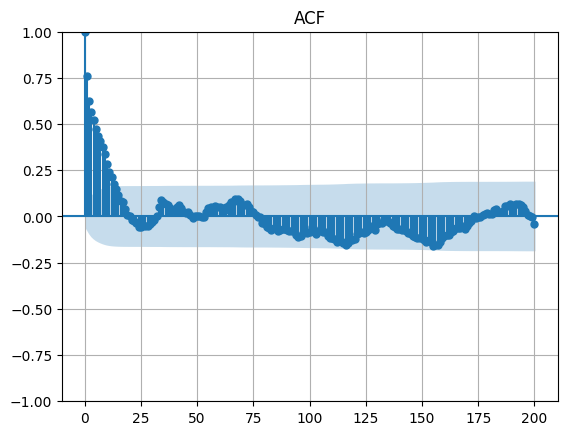

In [6]:
plot_acf(data_p_mnk, lags=200)
plt.title("ACF")
plt.grid()
plt.show()

(b) вычислите разности ∆P = (1 − L)P , где L – оператор сдвига назад.

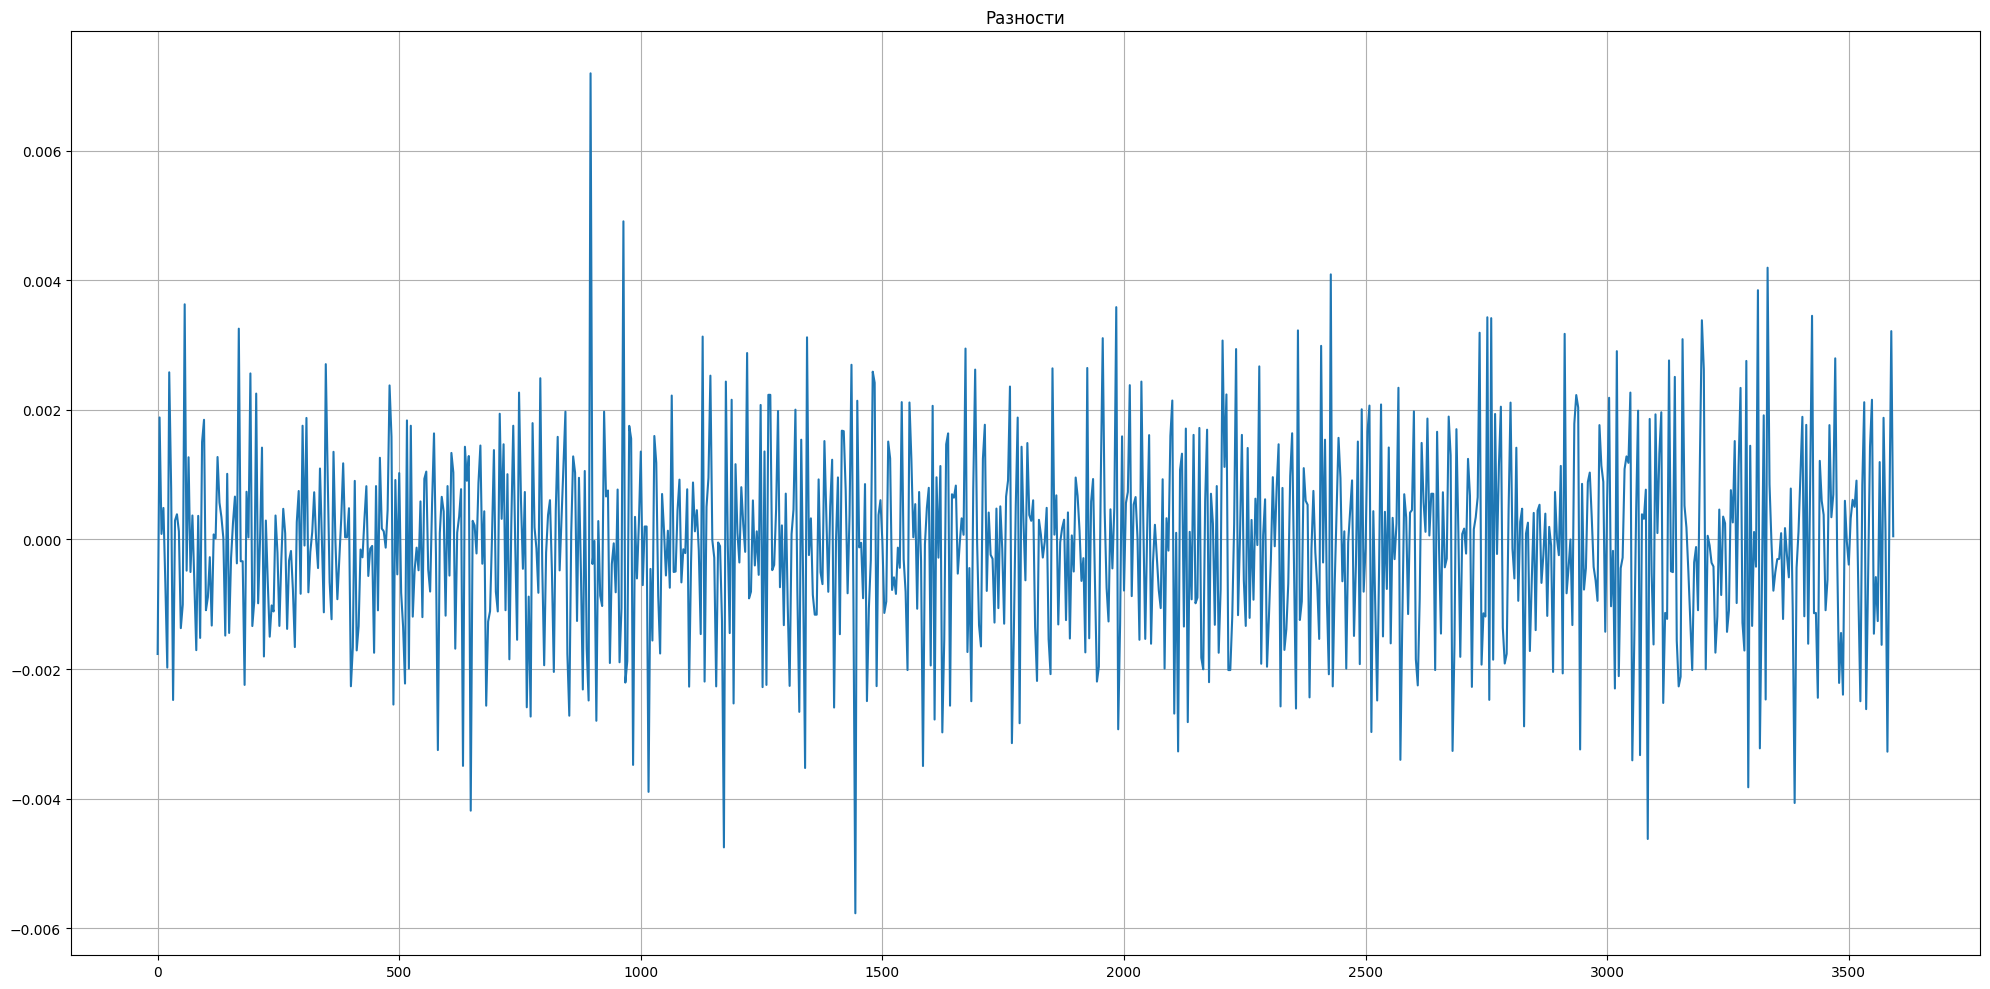

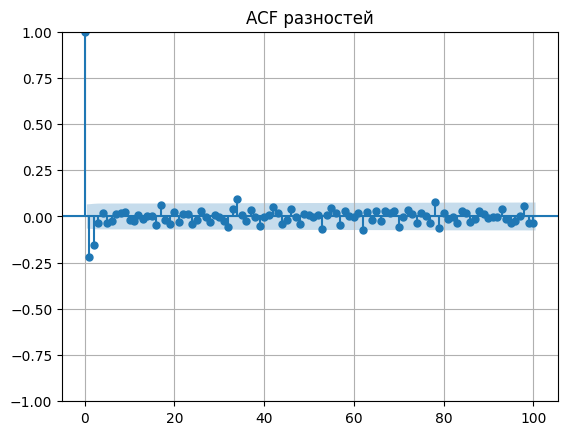

In [7]:
data_p_diff = np.diff(data_p)

plt.figure(figsize=(20, 10))
plt.plot(time_p[:-1], data_p_diff)
plt.title("Разности")
plt.grid()
plt.tight_layout()
plt.show()

plot_acf(data_p_diff, lags=100)
plt.title("ACF разностей")
plt.grid()

plt.show()

3. Решите эту задачу с помощью критерия Дики-Фуллера. Для этого:

- выберите одну из моделей критерия (AR, ARD или TS);
- проверьте значимость коэффициентов при вспомогательных членах и определите порядок
авторегрессии;
- проверьте гипотезы относительно основных коэффициентов модели Дики-Фуллера.

In [8]:
models = {
    'AR': 'n',    # no constant
    'ARD': 'c',    # constant
    'TS': 'ct',    # constant + trend
    'Квадратичный тренд': 'ctt'
}

for name, regression_type in models.items():
    print(f"\n===== ADF Test — Модель: {name} =====")
    
    result = adfuller(data_p, regression=regression_type, autolag='AIC')

    test_stat = result[0]
    p_value = result[1]
    used_lag = result[2]
    n_obs = result[3]
    crit_vals = result[4]

    print(f"ADF статистика: {test_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Использовано лагов: {used_lag}")
    print(f"Число наблюдений: {n_obs}")
    print("Критические значения:")
    for key, val in crit_vals.items():
        print(f"  {key}: {val:.4f}")

    # Вывод гипотезы
    if p_value < 0.05:
        print("✅ Отвергаем H0: ряд стационарен")
    else:
        print("❌ Не отвергаем H0: ряд нестационарен")

    # Значимость коэффициентов (OLS-регрессия по тем же данным)
    delta_y = np.diff(data_p)
    lagged_y = data_p[:-1]

    Y = delta_y[used_lag:]
    X = lagged_y[used_lag:]

    # Добавляем лаги дельт
    for i in range(1, used_lag + 1):
        X = np.column_stack((X, delta_y[used_lag - i: -i]))

    # Добавляем константу или тренд, если нужно
    if regression_type == 'c':
        X = sm.add_constant(X)
    elif regression_type == 'ct':
        trend = np.arange(len(X))
        X = sm.add_constant(np.column_stack((trend, X)))

    model_reg = sm.OLS(Y, X).fit()
    print("\n--- Вспомогательная регрессия (OLS) ---")
    print(model_reg.summary())



===== ADF Test — Модель: AR =====
ADF статистика: -2.8103
p-value: 0.0048
Использовано лагов: 6
Число наблюдений: 893
Критические значения:
  1%: -2.5682
  5%: -1.9413
  10%: -1.6165
✅ Отвергаем H0: ряд стационарен

--- Вспомогательная регрессия (OLS) ---
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.126
Model:                            OLS   Adj. R-squared (uncentered):              0.119
Method:                 Least Squares   F-statistic:                              18.30
Date:                Fri, 02 May 2025   Prob (F-statistic):                    7.76e-23
Time:                        20:40:15   Log-Likelihood:                          4598.1
No. Observations:                 893   AIC:                                     -9182.
Df Residuals:                     886   BIC:                                     -9149.
Df Model:                           7  

#### *Сезонность (периодическая составляющая)* ####

1. Постройте график зависимости расхода от времени (“облако точек”) и его автокорреляционную функцию. 

   Определите, имеется ли периодическая составляющая, оцените ее период k.

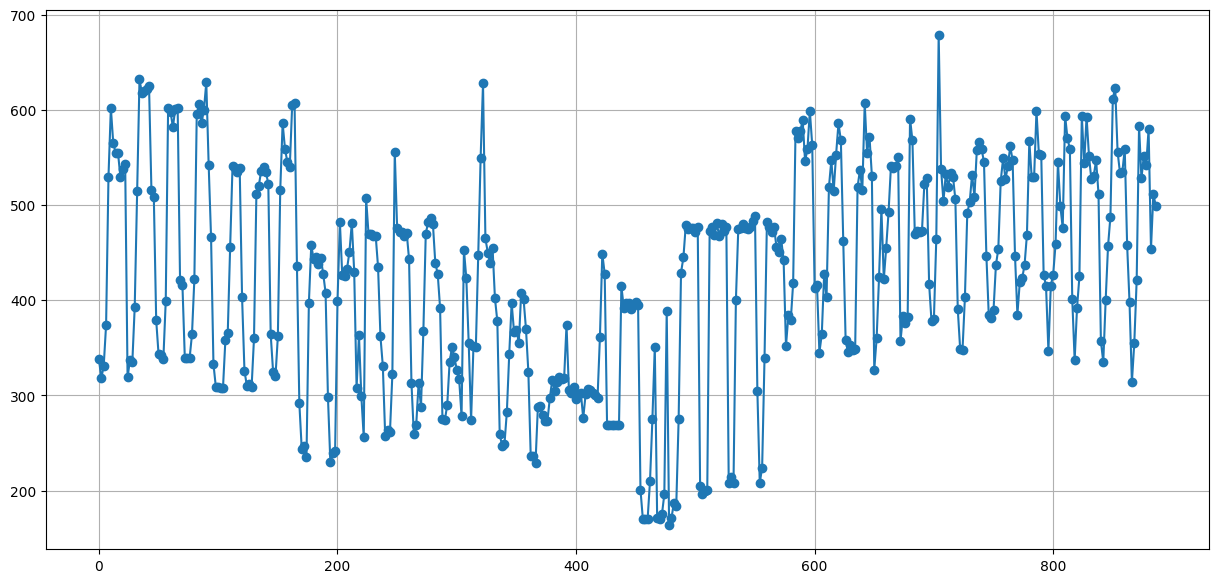

In [9]:
plt.figure(figsize=(15, 7))
plt.plot(time_q, data_q, '-o')
plt.grid()
plt.show()

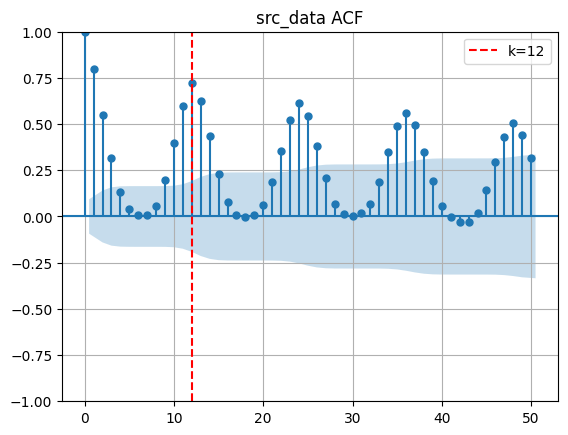

In [10]:
plot_acf(data_q, lags=50)
plt.axvline(x=12, color='r', linestyle='--', label='k=12')
plt.title("src_data ACF")
plt.legend()
plt.grid()
plt.show()

2. Удалите тренд с помощью последовательных разностей, $q = ∆^dQ$.

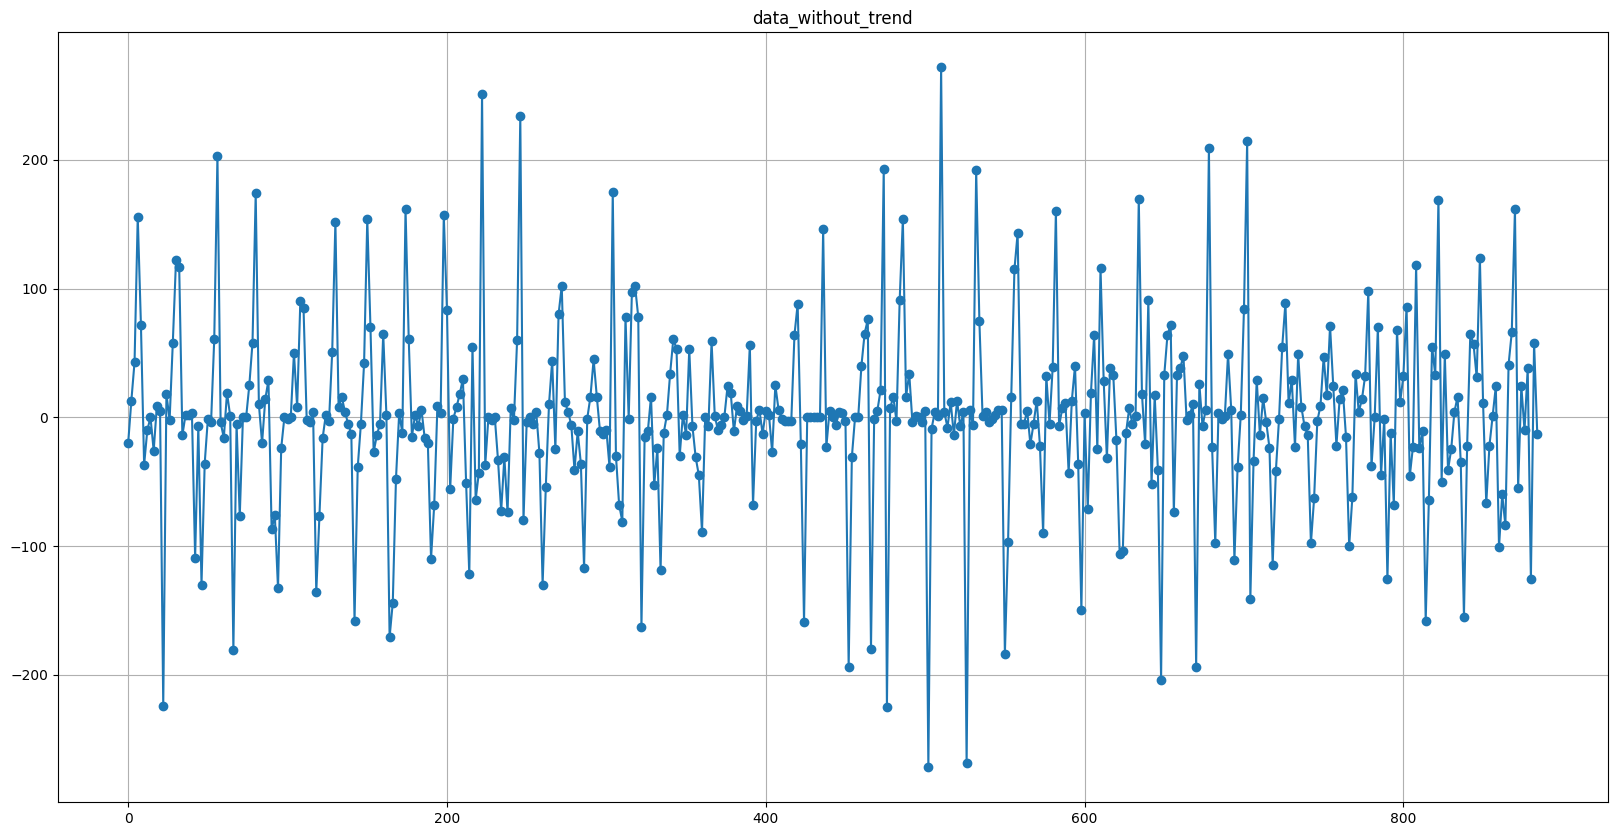

In [11]:
data_q_diff = np.diff(data_q)

plt.figure(figsize=(20, 10))
plt.plot(time_q[:-1], data_q_diff, "-o")
plt.title("data_without_trend")
plt.grid()
plt.show()

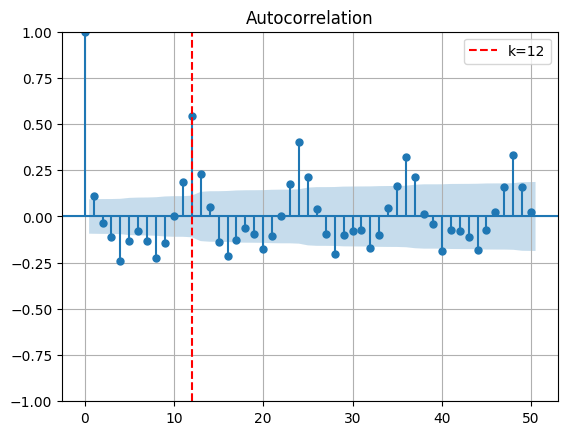

In [12]:
plot_acf(data_q_diff, lags=50)
plt.axvline(x=12, color='r', linestyle='--', label='k=12')
plt.legend()
plt.grid()
plt.show()

3. Попробуйте привести ряд без тренда q к стационарному виду следующими методами:

(a) методом наименьших квадратов оцените периодический тренд в виде тригонометрического разложения (отрезка ряда Фурье);

In [13]:
# Удаление тренда разностями
N = len(data_q_diff)
t = np.arange(N)

# Задаём период
period = 12

In [14]:
# Формируем X: тригонометрическое разложение
X_base = np.ones((N, 1))  # Столбец константы
for i in range(1, period + 1):
    cos_term = np.cos(2 * np.pi * i * t / period).reshape(-1, 1)
    sin_term = np.sin(2 * np.pi * i * t / period).reshape(-1, 1)
    X_base = np.hstack((X_base, cos_term, sin_term))

data_q_diff = data_q_diff.astype(float)
X_base = X_base.astype(float)

In [15]:
# МНК-модель
model_full = sm.OLS(data_q_diff, X_base).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     14.48
Date:                Fri, 02 May 2025   Prob (F-statistic):           3.24e-40
Time:                        20:40:17   Log-Likelihood:                -2394.2
No. Observations:                 443   AIC:                             4836.
Df Residuals:                     419   BIC:                             4935.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.308e+10   3.06e+10      1.406      0.1

C:\Users\kosti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\kosti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


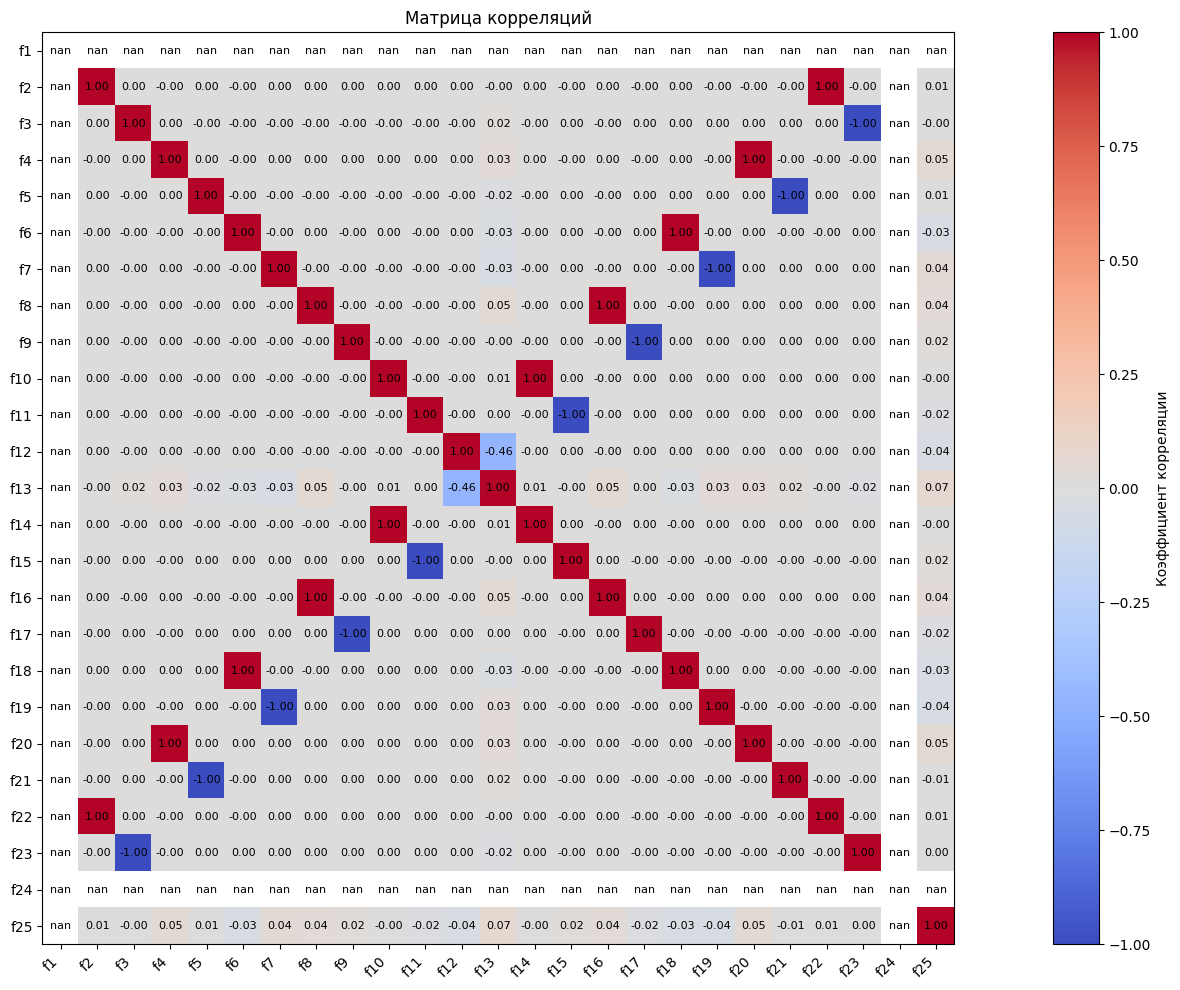

In [16]:
# std = X_base.std(axis=0)
# const_cols = np.where(std == 0)[0]
# # print("Индекс(ы) константных столбцов:", const_cols)

# X_clean = np.delete(X_base, const_cols, axis=1)
corr = np.corrcoef(X_base, rowvar=False)

# 2. Строим тепловую карту:
fig, ax = plt.subplots(figsize=(20, 10))
im = ax.imshow(corr, interpolation='nearest', cmap='coolwarm')
ax.set_title("Матрица корреляций")
ax.set_xticks(np.arange(corr.shape[0]))
ax.set_yticks(np.arange(corr.shape[0]))
# Подписи осей — по номерам признаков; при желании можно заменить на свои метки:
labels = [f"f{i}" for i in range(1, corr.shape[0]+1)]
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# 3. Добавляем цветовую шкалу:
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Коэффициент корреляции")

# 4. По желанию: добавить значения поверх ячеек
for i in range(corr.shape[0]):
    for j in range(corr.shape[0]):
        text = ax.text(j, i, f"{corr[i, j]:.2f}",
                       ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()

In [17]:
# --- ФИЛЬТРАЦИЯ НЕЗНАЧИМЫХ ПРИЗНАКОВ ---
significant_indices = model_full.pvalues < 0.05
X_filtered = X_base[:, [False, False, False, False, False, False, False, True, False, False, False, False, 
                        False, False, True, False, True, False, False, True, True, True, True, True, False]]

coeff_filtered = model_full.params[[False, False, False, False, False, False, False, True, False, False, False, False,
                                    False, False, True, False, True, False, False, True, True, True, True, True, False]]

C:\Users\kosti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\kosti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


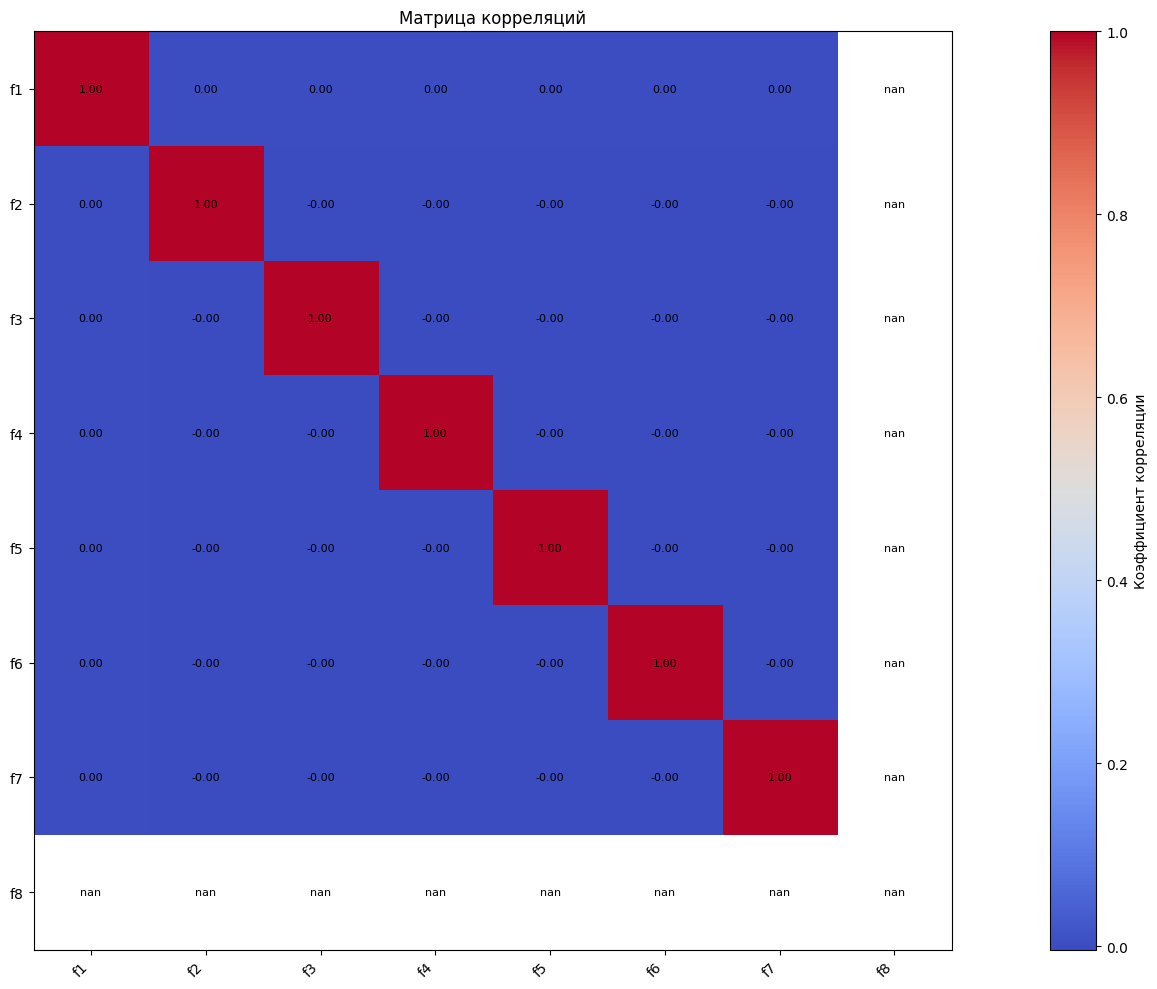

1.4231455586174884


In [18]:
# std = X_base.std(axis=0)
# const_cols = np.where(std == 0)[0]
# # print("Индекс(ы) константных столбцов:", const_cols)

# X_clean = np.delete(X_base, const_cols, axis=1)
corr = np.corrcoef(X_filtered, rowvar=False)

# 2. Строим тепловую карту:
fig, ax = plt.subplots(figsize=(20, 10))
im = ax.imshow(corr, interpolation='nearest', cmap='coolwarm')
ax.set_title("Матрица корреляций")
ax.set_xticks(np.arange(corr.shape[0]))
ax.set_yticks(np.arange(corr.shape[0]))
# Подписи осей — по номерам признаков; при желании можно заменить на свои метки:
labels = [f"f{i}" for i in range(1, corr.shape[0]+1)]
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# 3. Добавляем цветовую шкалу:
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Коэффициент корреляции")

# 4. По желанию: добавить значения поверх ячеек
for i in range(corr.shape[0]):
    for j in range(corr.shape[0]):
        text = ax.text(j, i, f"{corr[i, j]:.2f}",
                       ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()


print(np.linalg.cond(X_filtered))

In [19]:
# Повторная регрессия с отфильтрованными признаками
model_filtered = sm.OLS(data_q_diff, X_filtered).fit()
trend_filtered = model_filtered.predict(X_filtered)
residuals_filtered = data_q_diff - trend_filtered

In [20]:
# Размерности моделей
n = len(data_q_diff)  # число наблюдений
p_full = X_base.shape[1]
p_reduced = X_filtered.shape[1]

# Остаточные суммы квадратов
RSS_full = np.sum((data_q_diff - model_full.predict(X_base))**2)
RSS_reduced = np.sum((data_q_diff - trend_filtered)**2)

# Вычисление F-статистики
numerator = (RSS_reduced - RSS_full) / (p_full - p_reduced)
denominator = RSS_full / (n - p_full)
F_stat = numerator / denominator

# p-value
p_val = 1 - f.cdf(F_stat, p_full - p_reduced, n - p_full)

print("\n===== F-тест значимости отброшенных признаков =====")
print(f"F-статистика: {F_stat:.4f}")
print(f"p-value: {p_val:.4f}")
if p_val < 0.05:
    print("❌ Удалённые признаки значимы в совокупности — нельзя удалять")
else:
    print("✅ Удалённые признаки не значимы — удаление оправдано")


===== F-тест значимости отброшенных признаков =====
F-статистика: 1.7995
p-value: 0.0260
❌ Удалённые признаки значимы в совокупности — нельзя удалять


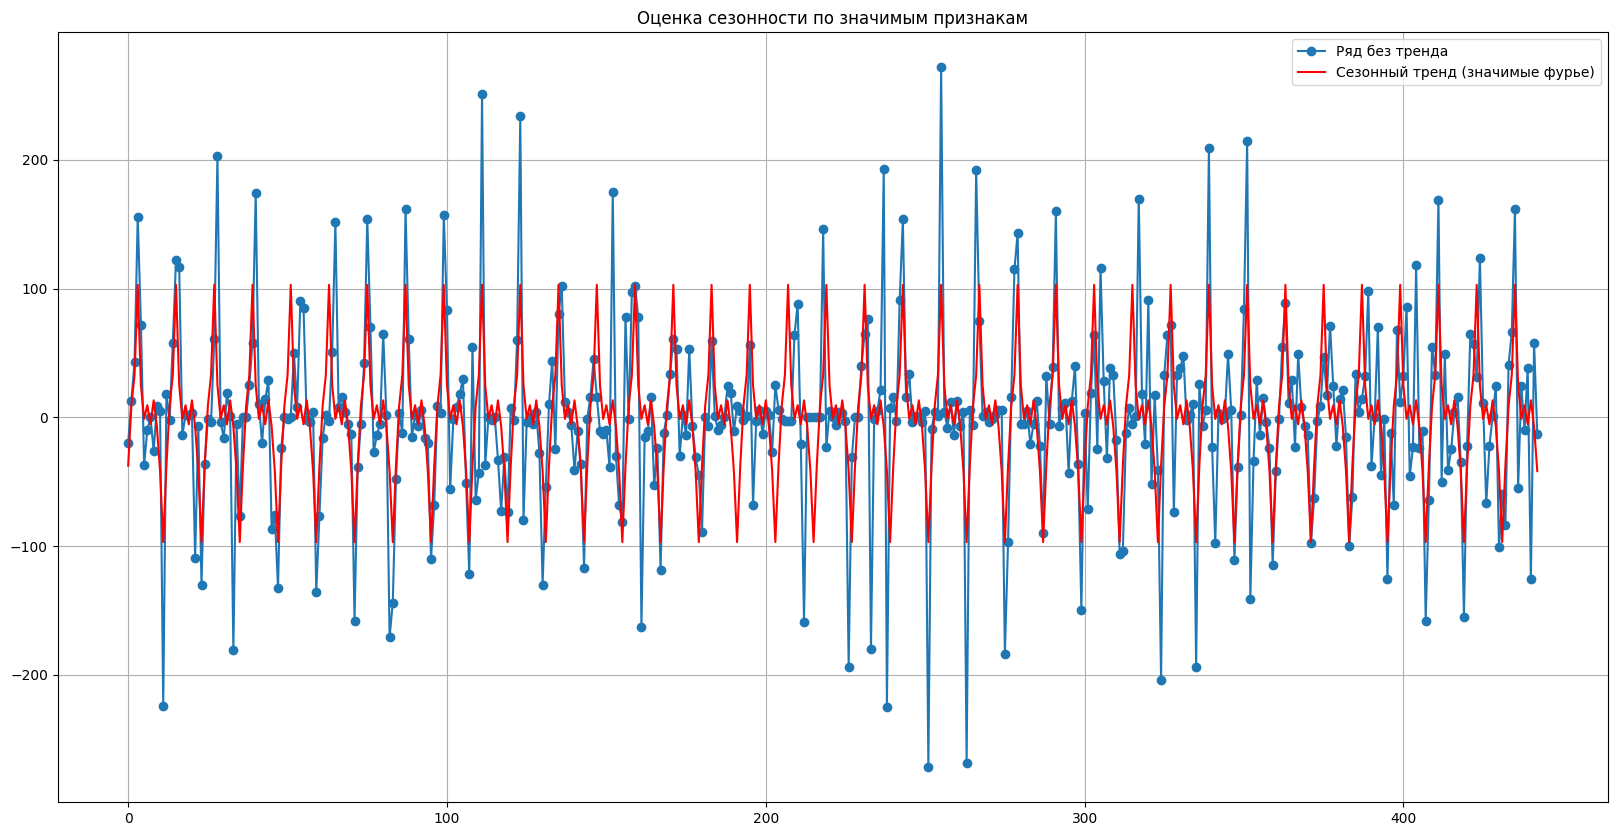

In [21]:
# --- ГРАФИКИ ---
# Сглаженный тренд
plt.figure(figsize=(20, 10))
plt.plot(data_q_diff, "-o", label="Ряд без тренда")
plt.plot(trend_filtered, "r", label="Сезонный тренд (значимые фурье)", linestyle="-")
plt.title("Оценка сезонности по значимым признакам")
plt.legend()
plt.grid()
plt.show()

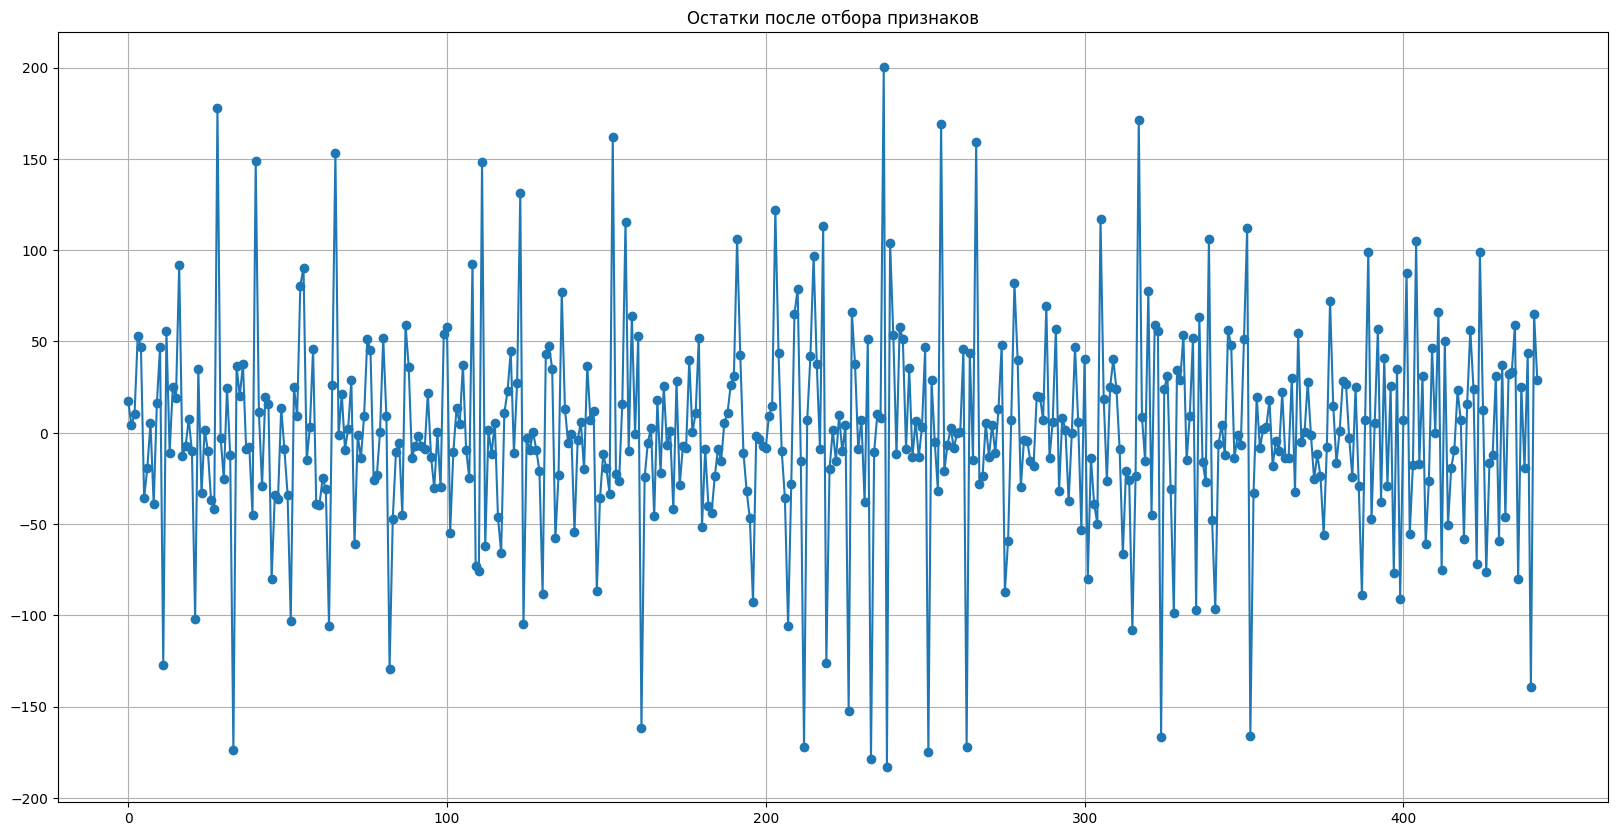

In [22]:
# Остатки
plt.figure(figsize=(20, 10))
plt.plot(residuals_filtered, "-o", label="Остатки после фильтрации")
plt.title("Остатки после отбора признаков")
plt.grid()
plt.show()

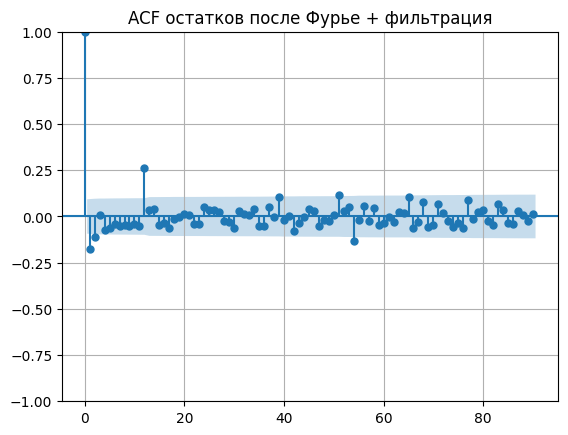

In [23]:
# ACF остатков
plot_acf(residuals_filtered, lags=90)
plt.title("ACF остатков после Фурье + фильтрация")
plt.grid()
plt.show()

In [24]:
var_1 = np.var(residuals_filtered)
print(f"Дисперсия: {var_1}")

Дисперсия: 3108.6230396825786


(b) введите индикаторы (булевы переменные) для каждого времени суток (0 ч, 2 ч, ..., 24 ч) и методом наименьших квадратов оцените коэффициенты;

In [25]:
time_q = time_q[1:]

# Индексы времени суток (12 слотов по 2 часа)
period = 12
slot_idx = (time_q % 24) // 2
N = len(data_q_diff)

# Матрица индикаторов
X_full = np.zeros((N, period))
for i in range(N):
    X_full[i, int(slot_idx[i])] = 1

# МНК модель с полным набором признаков
model_full = sm.OLS(data_q_diff, X_full).fit()
print("=== Полная модель (все индикаторы) ===")
print(model_full.summary())

# Отбор значимых признаков по t-критерию
significant_mask = model_full.pvalues < 0.05
X_reduced = X_full[:, significant_mask]
removed_mask = ~significant_mask
removed_indices = np.where(removed_mask)[0]

print(f"\nИндикаторы с p > 0.05 (будут удалены): {removed_indices.tolist()}")

# Модель без незначимых признаков
model_reduced = sm.OLS(data_q_diff, X_reduced).fit()

# F-тест: значимы ли удалённые признаки в совокупности?
n = len(data_q_diff)
p_full = X_full.shape[1]
p_reduced = X_reduced.shape[1]

# Остаточные суммы квадратов
RSS_full = np.sum((data_q_diff - model_full.predict(X_full))**2)
RSS_reduced = np.sum((data_q_diff - model_reduced.predict(X_reduced))**2)

# F-статистика
df1 = p_full - p_reduced
df2 = n - p_full
F_stat = ((RSS_reduced - RSS_full) / df1) / (RSS_full / df2)
p_value_f = 1 - f.cdf(F_stat, df1, df2)

print("\n=== F-тест значимости удалённых признаков ===")
print(f"F-статистика: {F_stat:.4f}")
print(f"p-value: {p_value_f:.4f}")
if p_value_f < 0.05:
    print("❌ Удалённые признаки значимы в совокупности — удалять нельзя!")
else:
    print("✅ Удалённые признаки незначимы в совокупности — удаление оправдано.")

=== Полная модель (все индикаторы) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     27.39
Date:                Fri, 02 May 2025   Prob (F-statistic):           2.94e-43
Time:                        20:40:25   Log-Likelihood:                -2406.4
No. Observations:                 443   AIC:                             4837.
Df Residuals:                     431   BIC:                             4886.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1          -

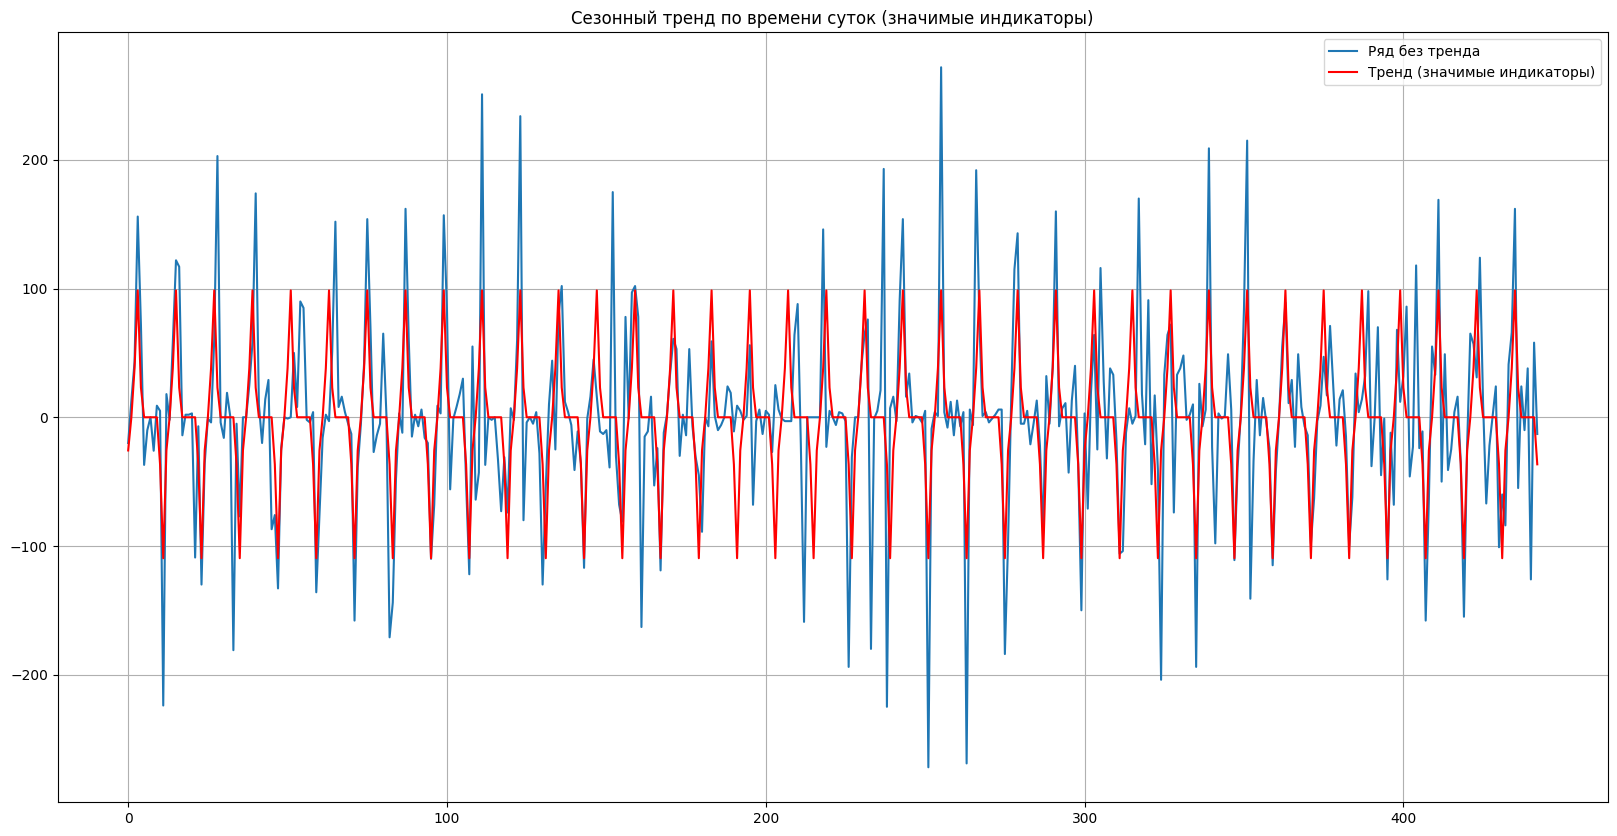

In [26]:
# Предсказания и остатки
trend_reduced = model_reduced.predict(X_reduced)
residuals_reduced = data_q_diff - trend_reduced

# Визуализация
plt.figure(figsize=(20, 10))
plt.plot(data_q_diff, label="Ряд без тренда")
plt.plot(trend_reduced, "r",label="Тренд (значимые индикаторы)", linestyle="-")
plt.title("Сезонный тренд по времени суток (значимые индикаторы)")
plt.legend()
plt.grid()
plt.show()

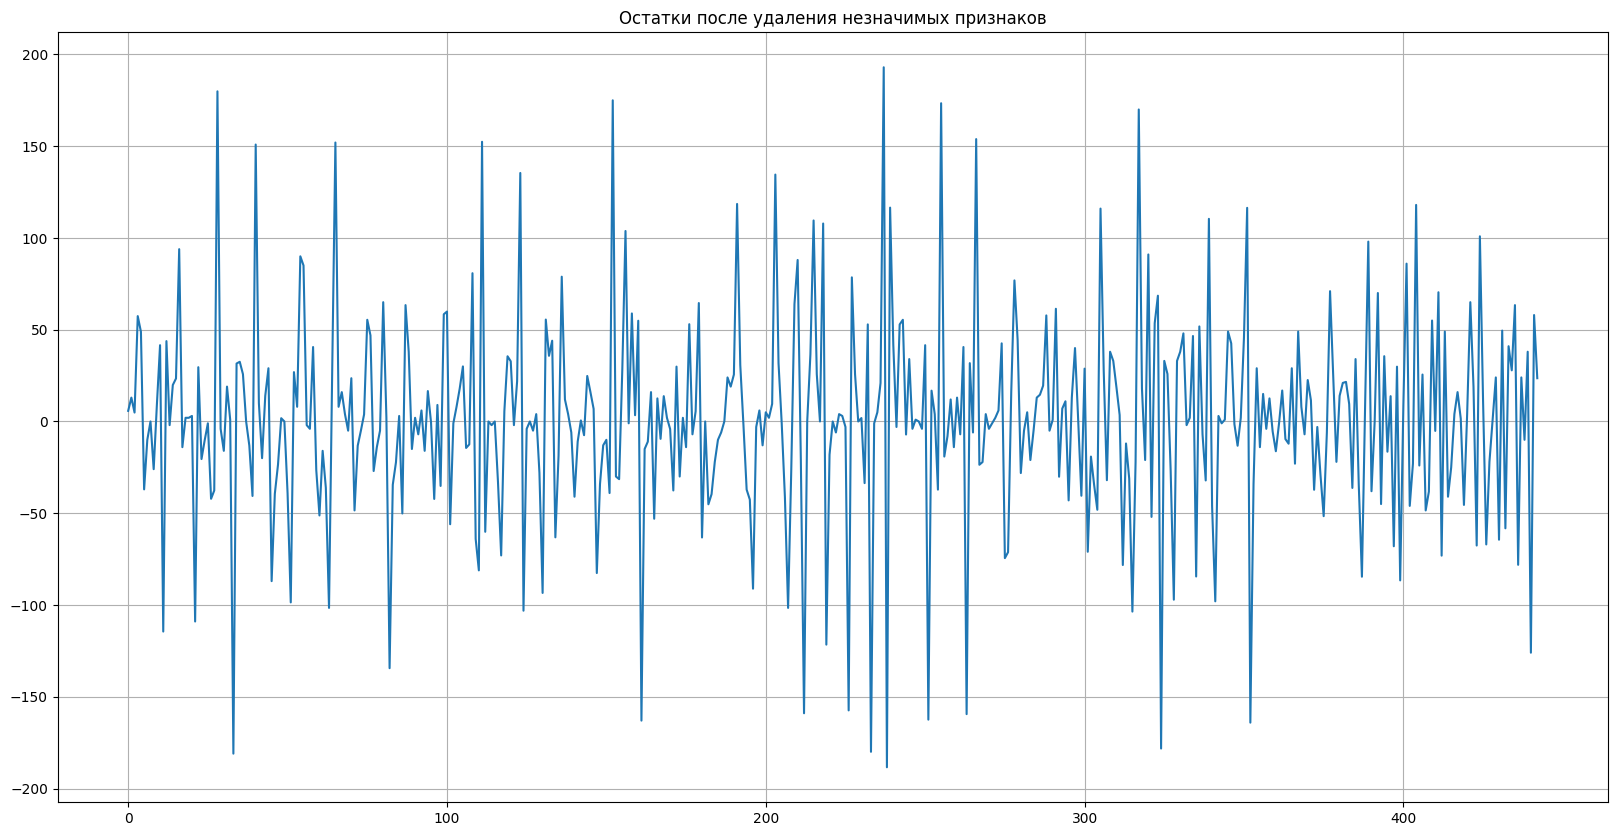

In [27]:
plt.figure(figsize=(20, 10))
plt.plot(residuals_reduced)
plt.title("Остатки после удаления незначимых признаков")
plt.grid()
plt.show()

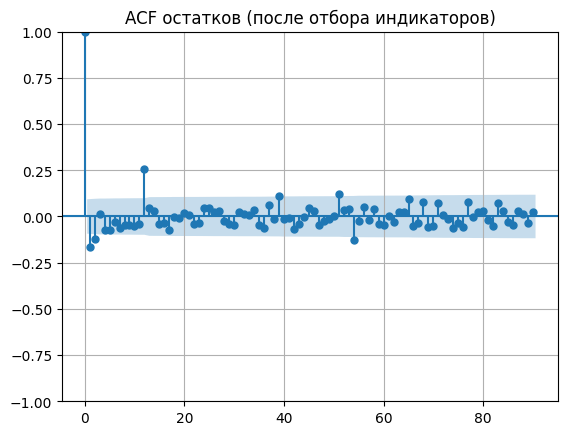

In [28]:
plot_acf(residuals_reduced, lags=90)
plt.title("ACF остатков (после отбора индикаторов)")
plt.grid()
plt.show()

In [29]:
var_2 = np.var(residuals_reduced)
print(f"Дисперсия: {var_2}")

Дисперсия: 3078.114112847873


(c) вычислите периодический тренд как средние значения для каждого часа;

есть ли отличия от предыдущего результата?

In [30]:
# Средние значения по слотам
slot_means = np.array([
    data_q_diff[slot_idx == i].mean() for i in range(period)
])

slot_means

array([-109.52777778,  -25.78378378,    1.81081081,   38.13513514,
         98.59459459,   23.10810811,    7.48648649,    0.97297297,
         -1.91891892,   11.37837838,   -6.2972973 ,  -36.56756757])

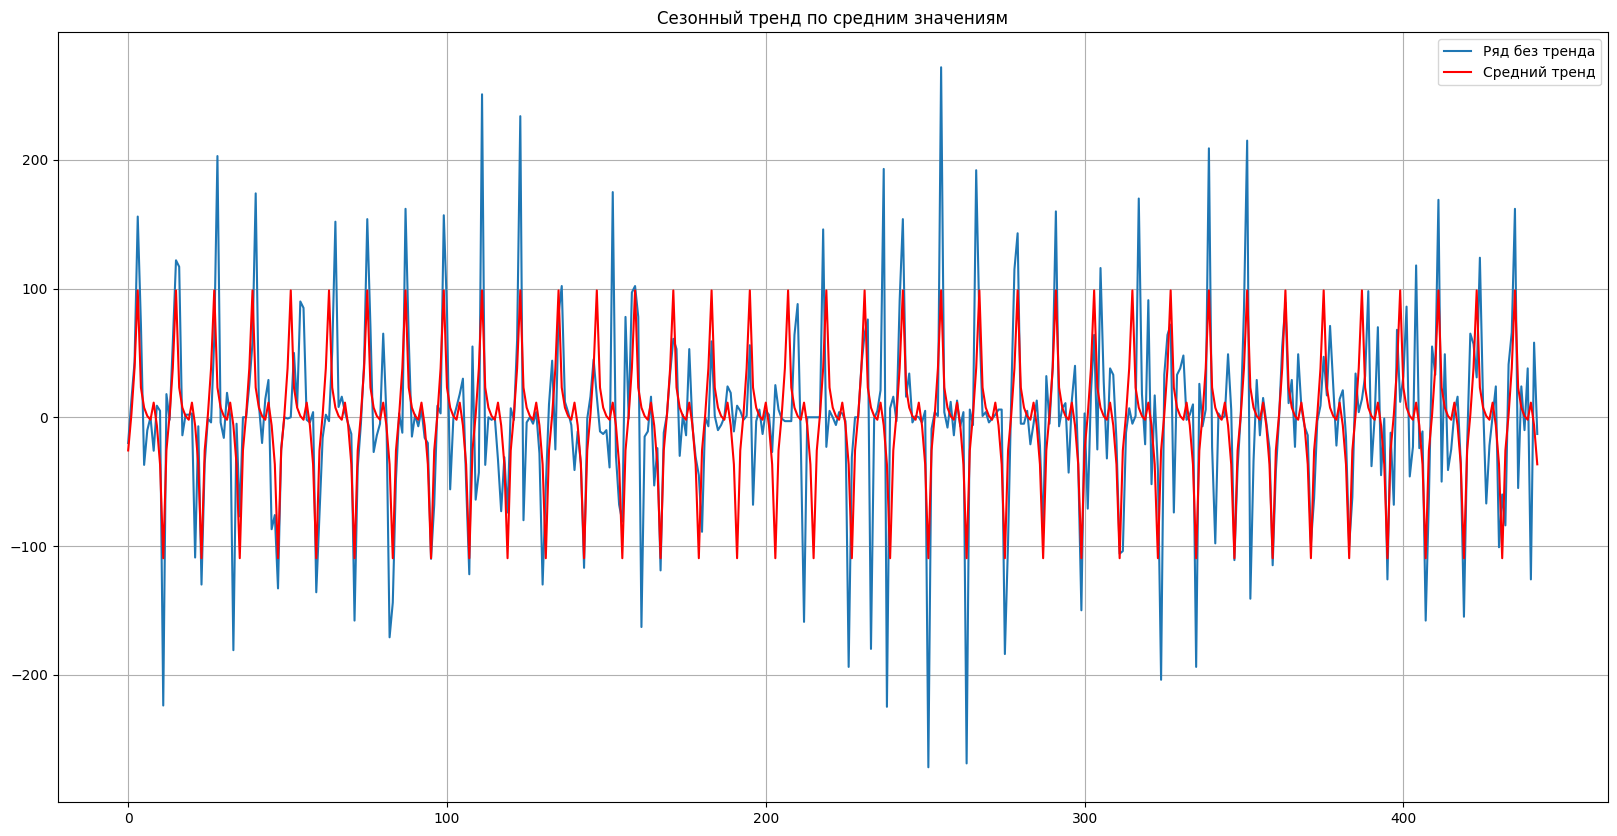

In [31]:
# Построение тренда
trend_avg = np.array([slot_means[int(i)] for i in slot_idx])

# Остатки
residuals_avg = data_q_diff - trend_avg

# График тренда
plt.figure(figsize=(20, 10))
plt.plot(data_q_diff, label="Ряд без тренда")
plt.plot(trend_avg, "r", label="Средний тренд", linestyle="-")
plt.title("Сезонный тренд по средним значениям")
plt.legend()
plt.grid()
plt.show()

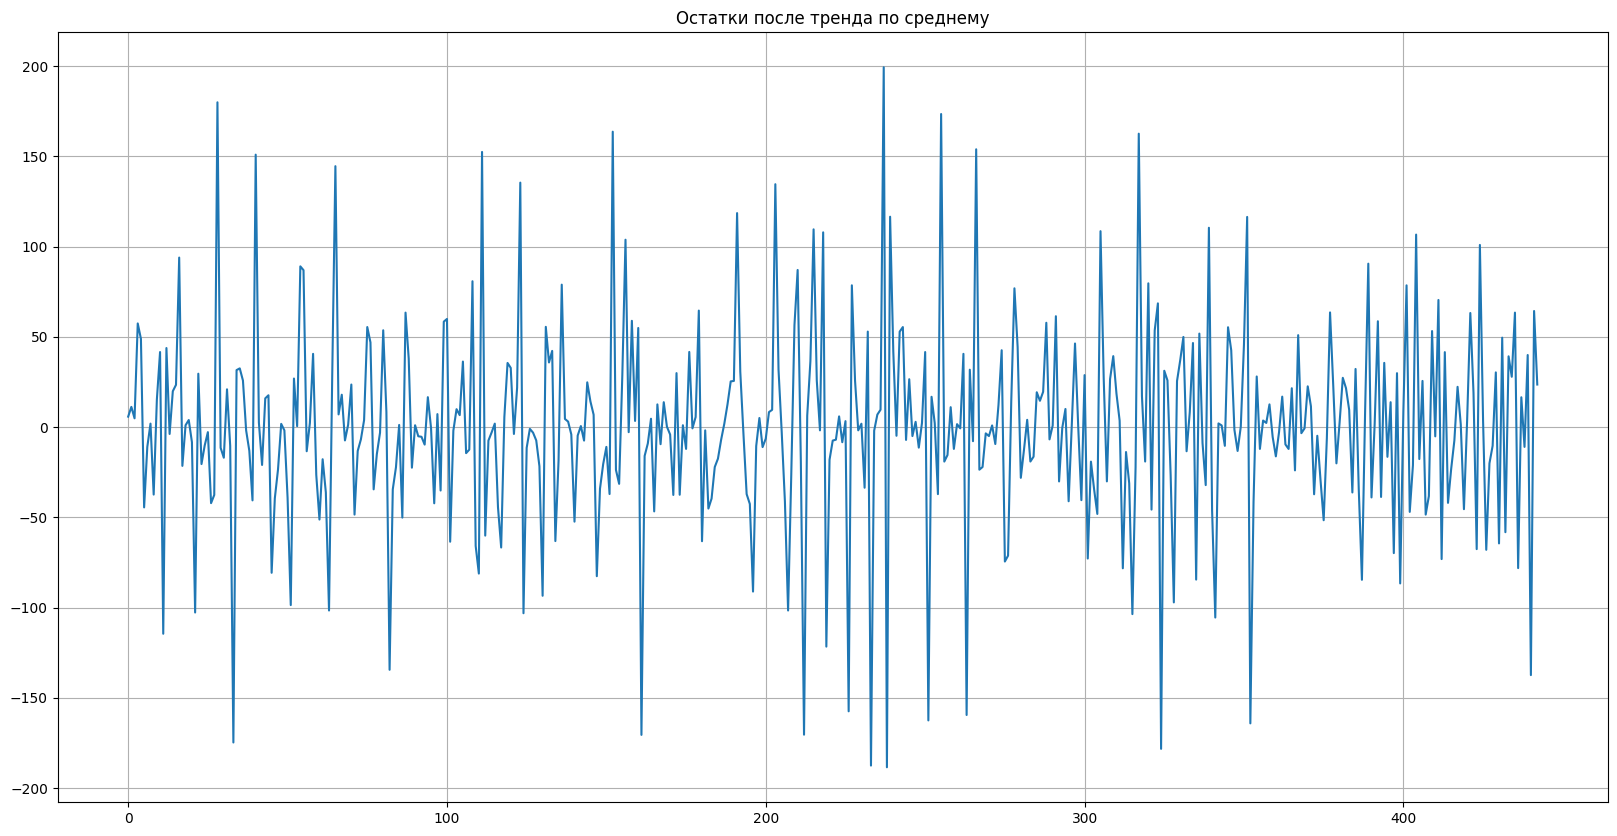

In [32]:
# Остатки
plt.figure(figsize=(20, 10))
plt.plot(residuals_avg)
plt.title("Остатки после тренда по среднему")
plt.grid()
plt.show()

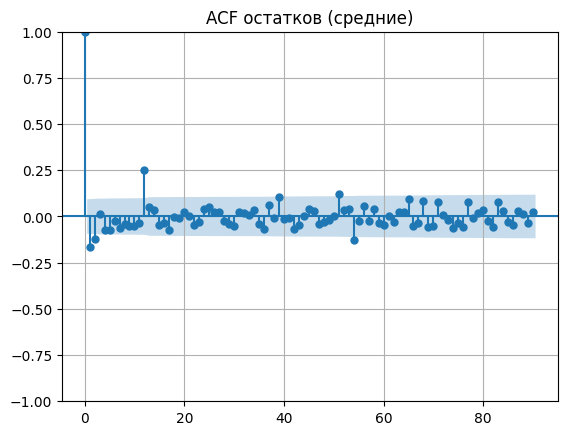

In [33]:
# ACF остатков
plot_acf(residuals_avg, lags=90)
plt.title("ACF остатков (средние)")
plt.grid()
plt.show()

In [34]:
var_3 = np.var(residuals_avg)
print(f"Дисперсия: {var_3}")

Дисперсия: 3059.9056782516154


(d) вычислите периодические (сезонные) разности $\Delta_k q = (1-L^k)q$

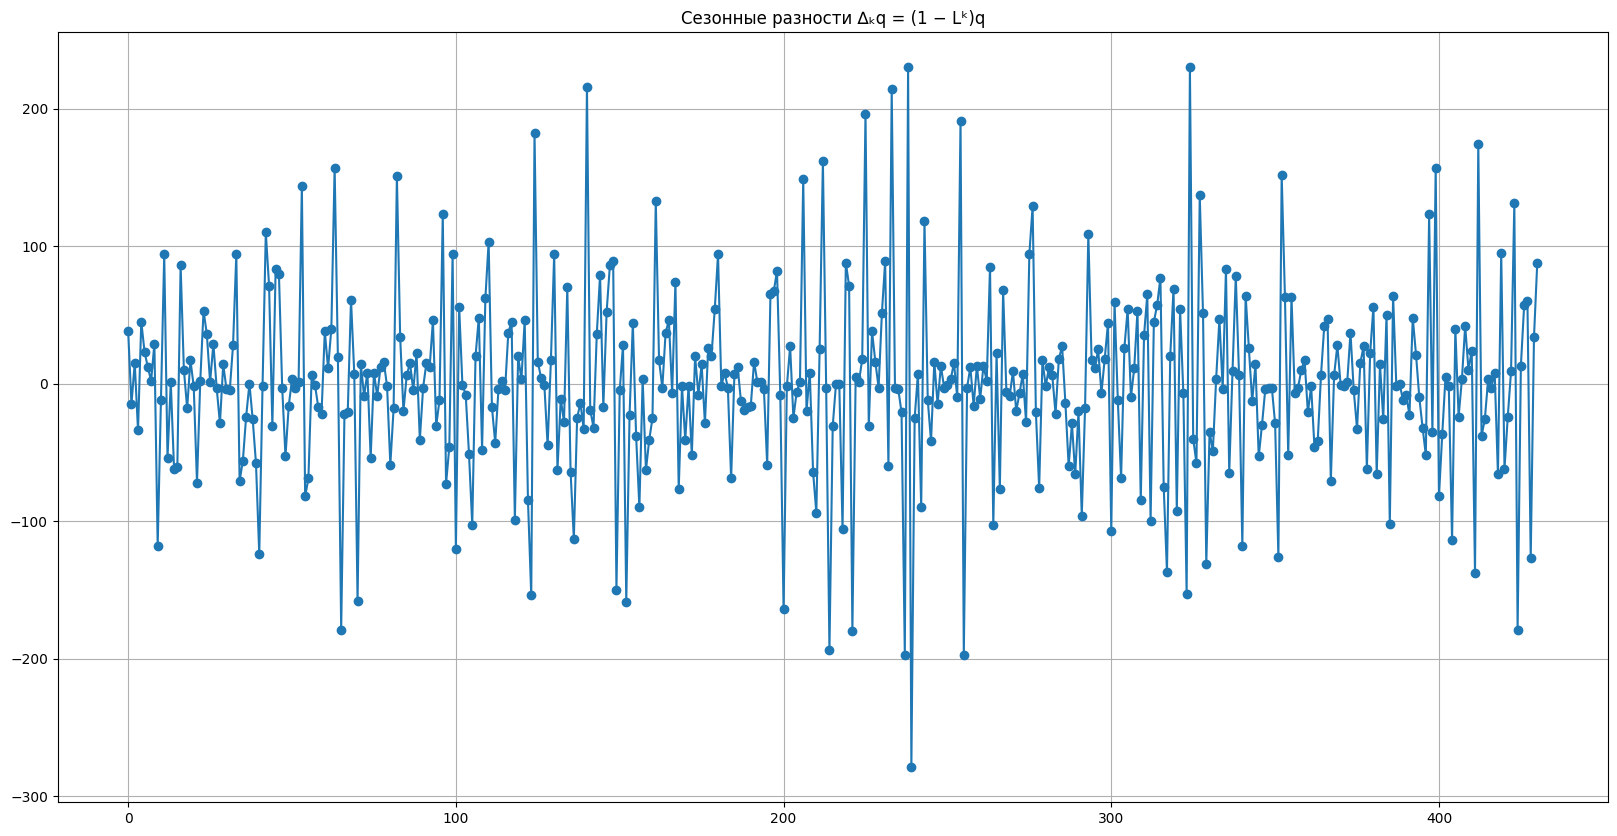

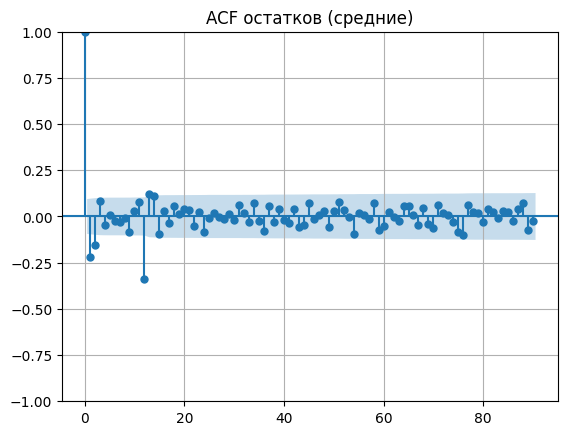

In [35]:
# Сезонные разности: ∆kq = q[t] - q[t-k]
k = 12
seasonal_diff = data_q_diff[k:] - data_q_diff[:-k]

# Визуализация сезонных разностей
plt.figure(figsize=(20, 10))
plt.plot(seasonal_diff, "-o")
plt.title("Сезонные разности ∆ₖq = (1 − Lᵏ)q")
plt.grid()
plt.show()

plot_acf(seasonal_diff, lags=90)
plt.title("ACF остатков (средние)")
plt.grid()
plt.show()

In [36]:
var_4 = np.var(seasonal_diff)
print(f"Дисперсия: {var_4}")

Дисперсия: 4550.532824435699


In [37]:
data = {
    'variance': [var_1, var_2, var_3, var_4],
    'метод': [
        'Тригонометрическое разложение (ряд Фурье)',
        'Индикаторы для каждого времени суток',
        'Средние значения для каждого часа',
        'Периодические (сезонные) разности'
    ]
}

df_variance = pd.DataFrame(data)
df_variance

,variance,метод
0,3108.623040,Тригонометрическое разложение (ряд Фурье)
1,3078.114113,Индикаторы для каждого времени суток
2,3059.905678,Средние значения для каждого часа
3,4550.532824,Периодические (сезонные) разности
